In [1]:
# Download latest version
import kagglehub
# path = kagglehub.dataset_download("vinayaks0n1/ipl-2025")

In [2]:
# Show the path of downloaded file, I have copied this file and put it under' data' folder
#print(path)

In [3]:
# This one is for cricket enthusiasts. I have imported some stats for the bowlers
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_bowlers = pd.read_csv("data\\ipl-2025\\IPL2025Bowlers.csv")
df_bowlers.head()

,Player Name,Team,WKT,MAT,INN,OVR,RUNS,BBI,AVG,ECO,SR,4W,5W
0,Prasidh Krishna,GT,25,15,15,59.0,488,41/4,19.52,8.27,14.16,1,0
1,Noor Ahmad,CSK,24,14,14,50.0,408,18/4,17.00,8.16,12.50,2,0
2,Josh Hazlewood,RCB,22,12,12,44.0,386,33/4,17.54,8.77,12.00,1,0
3,Trent Boult,MI,22,16,16,57.4,517,26/4,23.50,8.96,15.72,1,0
4,Arshdeep Singh,PBKS,21,17,16,58.2,518,16/3,24.66,8.88,16.66,0,0


In [4]:
# Number of bowlers from each team in the dataset
df_bowlers.groupby('Team')['Player Name'].count().sort_values()

Team
DC       8
CSK      9
KKR      9
RCB     10
RR      10
GT      11
SRH     11
LSG     13
MI      13
PBKS    14
Name: Player Name, dtype: int64

 #### Task 1 : Sampling distribution of a statistic

In [5]:
df_bowlers.head()

,Player Name,Team,WKT,MAT,INN,OVR,RUNS,BBI,AVG,ECO,SR,4W,5W
0,Prasidh Krishna,GT,25,15,15,59.0,488,41/4,19.52,8.27,14.16,1,0
1,Noor Ahmad,CSK,24,14,14,50.0,408,18/4,17.00,8.16,12.50,2,0
2,Josh Hazlewood,RCB,22,12,12,44.0,386,33/4,17.54,8.77,12.00,1,0
3,Trent Boult,MI,22,16,16,57.4,517,26/4,23.50,8.96,15.72,1,0
4,Arshdeep Singh,PBKS,21,17,16,58.2,518,16/3,24.66,8.88,16.66,0,0


In [6]:
# A miscelleneous side exercise to convert a panda Series to Panda dataframe
df_bowlers_meanavg_by_team = df_bowlers.groupby('Team')['AVG'].mean()
print("type of df_bowlers_meanavg_by_team: ", type(df_bowlers_meanavg_by_team))
df_bowlers_meanavg_by_team = df_bowlers_meanavg_by_team.to_frame().reset_index()
print("After conversion to dataframe and resetting index: ", type(df_bowlers_meanavg_by_team))
df_bowlers_meanavg_by_team.head()

type of df_bowlers_meanavg_by_team:  <class 'pandas.core.series.Series'>
After conversion to dataframe and resetting index:  <class 'pandas.core.frame.DataFrame'>


,Team,AVG
0,CSK,46.192222
1,DC,45.895000
2,GT,41.968182
3,KKR,44.411111
4,LSG,42.851538


<Axes: xlabel='AVG', ylabel='Count'>

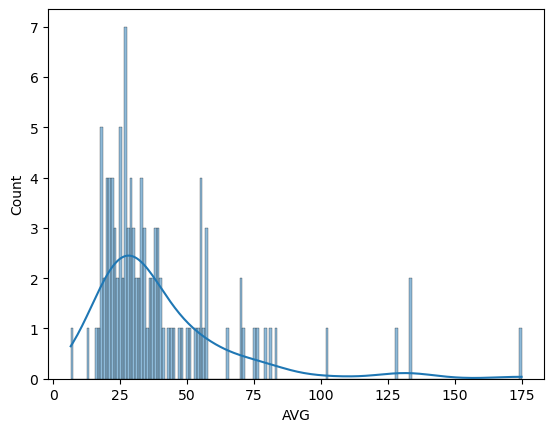

In [7]:
# Lets a make histogram to visualize bowling averages of all the bowlers
# Here kde is kernel density estimate, refer https://seaborn.pydata.org/generated/seaborn.histplot.html
#   for different types of plots like kde, ecdf (empirical cumulative distribution) etc.
#   NOTE: without the kde we will just get the histogram
sns.histplot(data=df_bowlers['AVG'], binwidth=1, kde=True)

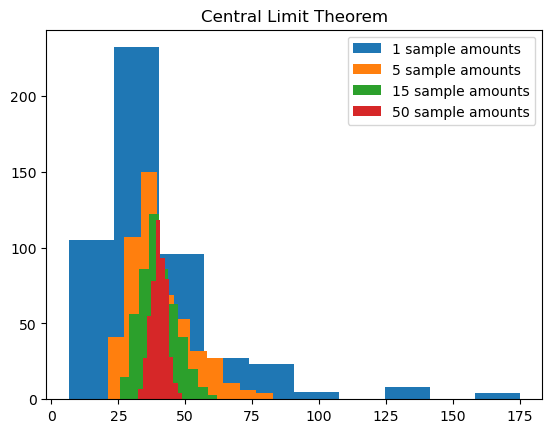

In [8]:
#The distribution of a sample statistic such as the mean is likely to be more regular and
#  bell-shaped than the distribution of the data itself. The larger the sample the statistic
#  is based on, the more this is true. Also, the larger the sample, the narrower the distri
#  bution of the sample statistic.

sample_amounts = [1, 5, 15, 50]

for s in sample_amounts:
    samples = []
    for _ in range(500):
        samples.append(df_bowlers['AVG'].sample(s).mean())
    plt.hist(samples)
plt.legend([str(x) + " sample amounts" for x in sample_amounts])
plt.title("Central Limit Theorem")
plt.show()

#### _In the above example we see that as we take more and more sample points the values seem to converge at the actual mean of the entire data_

### Standard Error = SE = s/sqrt(n) where s std deviation

In [9]:
# The metric that sums up the variability on sampling distribution
#    StandardError = SE = s/sqrt(n) where s std deviation
# this is how it is calculated 
# NOTE: Can be calculated differently for dataframes, numpy, statistics module in python

# Step 1. Collect a number of brand-new samples from the population.
# Step 2. For each sample, calculate the statistic and make a series (the statistic/metric is mean here)
# Step 3. Calculate the standard deviation of the statistics computed in step 2; use this as your estimate of standard error.

sample_size = [10, 30, 50]
samples = []

for samp in sample_size:
    for _ in range(500):
        samples.append(df_bowlers['AVG'].sample(samp).mean())
    pd_series = pd.Series(samples)
    std_error = pd_series.std(ddof = 1) / pd_series.count() ** 0.5 # ddof = 1 because denominator is n-1 for a sample
    alternate_method_std_error = pd_series.sem()
    print(f"Std Error for a sample size of {samp}: {std_error}")
    print(f"Std Error(built-in pandas alternate method --> pd_series.sem()) for a sample size of {samp}: {alternate_method_std_error}\n")
print("\nNOTE! See how the std error reduces with inc. in sample size")


Std Error for a sample size of 10: 0.3698113839680341
Std Error(built-in pandas alternate method --> pd_series.sem()) for a sample size of 10: 0.36981138396803404

Std Error for a sample size of 30: 0.20729267057404988
Std Error(built-in pandas alternate method --> pd_series.sem()) for a sample size of 30: 0.20729267057405

Std Error for a sample size of 50: 0.14399250937167785
Std Error(built-in pandas alternate method --> pd_series.sem()) for a sample size of 50: 0.14399250937167768


NOTE! See how the std error reduces with inc. in sample size


### Bootstrapping

In [10]:
# Drawing new samples to estimate standard error is statistically wasteful, an easier way to estimate the sampling
# distribution of a statistic is by bootstrapping. It is to draw additional samples WITH REPLACEMENT from the 
# sample itself and recalculate the statistic or model from each resample.

# Step 1: Resample from the sample and replace it
# Step 2: Repeat n-times
# Step 3: Calculate the MEAN of the n resampled values 
# Step 4: Repeat steps 1-3R times
# Step 5: Use the R results to:
#    a. Calculate std deviation (sample mean std. error)
#    b. Draw a histogram
#    c. Calculate confidence interval

# STEPS 1-4 are done in the code below and a deviation from the actual value is shown

from sklearn.utils import resample

results = []

for nrepeat in range(1000):
    sample = resample(df_bowlers['AVG'])
    results.append(sample.mean())

results = pd.Series(results)
print('Bootstrap Statistics (Mean):')
print(f"\toriginal (df_bowlers['AVG'].mean()): {df_bowlers['AVG'].mean()}")
print(f"\tresults.mean(): {results.mean()}")
print(f"\tbias (results.mean() - df_bowlers['AVG'].mean()): {results.mean() - df_bowlers['AVG'].mean()}")
print(f"\tstd. error (results.std()): {results.std()}")

print("\nNOTE!!! Bootstrapping does not assume Normal distribution and more stabe with smaller samples")

Bootstrap Statistics (Mean):
	original (df_bowlers['AVG'].mean()): 40.10851851851852
	results.mean(): 40.13440527777778
	bias (results.mean() - df_bowlers['AVG'].mean()): 0.025886759259257985
	std. error (results.std()): 2.5945347552487146

NOTE!!! Bootstrapping does not assume Normal distribution and more stabe with smaller samples


### Confidence Interval (CI) with t-tables & z-tables

$
\begin{array}{l}
\text{A confidence interval is defined as a range of values likely to contain the true population parameter OR statistic,} \\
\text{for ex. a 95\% confidence interval means that there is 95\% confidence that the true statistic under test (say avg. height) lies in that interval/range}
\text{Refer also the notes and Shashank's video lectures} \\
\\
\text{Refer also the notes and Shashank's video lectures}
\text{There are 2 ways to calculate CI, using t-tables and z-tables, t-tables are generally used for <30 values and z-tables for higher numbers >30 sample points}
\end{array}
$

1.&emsp; T-tables (< 30 sample points) $$CI = \hat{x} \pm T_{\frac{\alpha}{2}} * \frac{\sigma}{\sqrt{n}}$$
2.&emsp; Z-tables (> 30 sample points) $$CI = \hat{x} \pm Z_{\frac{\alpha}{2}} * \frac{\sigma}{\sqrt{n}}$$

#### Calculating by t-tables

In [11]:
# Calculating by t-tables
import scipy.stats as st
import numpy as np

# define the sample data which (here) is avg of 25 bowlers
avg_of_25_bowlers = df_bowlers['AVG'][:25]

# create the 95% population interval for population mean weight
st.t.interval(confidence=0.95, df=len(avg_of_25_bowlers)-1, loc=np.mean(avg_of_25_bowlers), scale=st.sem(avg_of_25_bowlers))

(np.float64(23.180458567212483), np.float64(27.447541432787517))

$
\\
\text{NOTE: The confidence interval(CI) can also be calculated after the Standard error(SE) step earlier in bootstrapping by CI formulas mentioned above}
$

#### Calculating by z-tables

In [12]:
# define the sample data which (here) is avg of 75 bowlers
# NOTE: workd better on much bigger sample size
avg_of_75_bowlers = df_bowlers['AVG'][:75]

# create the 95% population interval for population mean weight
st.norm.interval(confidence=0.95, loc=np.mean(avg_of_75_bowlers), scale=st.sem(avg_of_75_bowlers))

(np.float64(28.54429991482121), np.float64(34.568233418512115))

### QQ plot (Quantile Quantile plot)

$
\begin{array}{l}
\text{The purpose is to check whether the sample actually follows a normal distribution (ALSO CHECK NOTES!)} \\
\\
\text{STEPS}
\end{array}
$

1. Sort the sample in ascending order
2. Compute probability/assign probability (x_i is each value of sample and n is number of values in sample) -> Calculating area under curve
   $$p_i = \frac{x_i - 0.5}{n}$$
3. Calculate Z-score from the z-table for each p_i
4. Calculate sample mean, std.dev and from this the Expected normal values
   $$Expected_i = \hat{x} + \sigma z_i$$
5. Plot expected values on the x-axis, actual values on the y-axis and check if relationship is linear or not
   

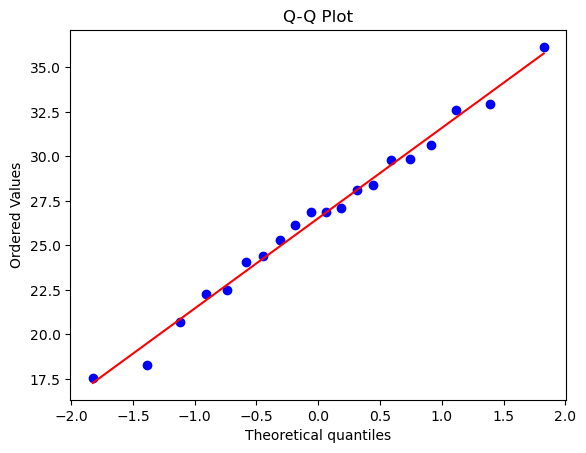

In [13]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# Lets consider 15 values
data = df_bowlers['AVG'][5:25]
# sort the values -> Not required if you use th ebuilt-in method to calculate QQ plot
# avg_15_bowlers.sort_values(inplace=True)
# NOTE: stats.norm.ppf(0.95) will return the 95th percentile, use when calculating all steps manually

# Calculate QQ plot
stats.probplot(data, dist="norm", plot=plt)

plt.title("Q-Q Plot")
plt.show()

## Binomial Distribution

$$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$$
$$ \binom{n}{k} = \frac{n!}{k!(n-k)!} $$
$
\begin{array}{l}
\text{p = Probability of success} \\
\end{array}
$

In [14]:
# Probability that coin shows heads exactly 2 times after 5 tosses
# PMF -> Probability mass function
stats.binom.pmf(2, n=5, p=0.5)

np.float64(0.31249999999999983)

In [15]:
# Probability that coin shows heads 2 times or less after 5 tosses
# CDF -> Cumulative distribution function
stats.binom.cdf(2, n=5, p=0.5)

np.float64(0.5)

## Poisson distrubution

$
\\
\text{Used to measure how many times something happens in a fixed interval. The probability mass function (PMF) for Poisson distribution:}
$

$$
P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}
$$

$ \text{
where:
$\lambda$ is the average rate of occurrence, $k$ is the number of occurrences
}
$

In [16]:
# If you get 2 calls every mimnute, what is the probability that you get exactly 3 calls (within a minute)
from scipy.stats import poisson
lam = 2
k = 3

poisson.pmf(lam, k)

np.float64(0.22404180765538775)

lambda = 2, 
k-values = [0.         0.18393972 0.27067057 0.22404181 0.14652511 0.08422434
 0.04461754 0.02234111 0.0107348  0.0049981 ]



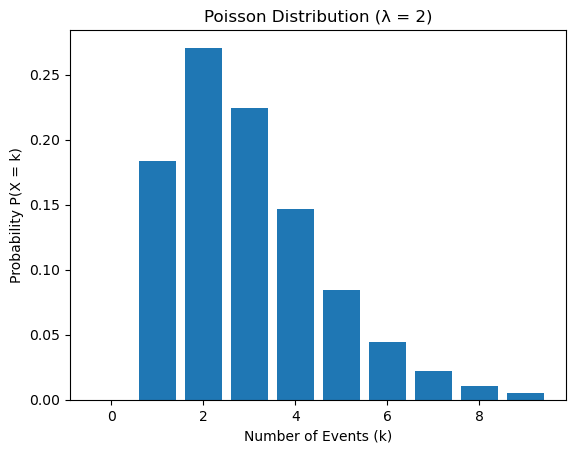

In [17]:
# Let's make a plot for 10 occurances
import numpy as np
import matplotlib.pyplot as plt

# make samples out of a 100 trials
samples = poisson.rvs(mu=2, size=100, random_state=2) # random_state 2 generates the same series of random numbers because it starts with seed as 2
x = np.arange(0, max(samples)+1)
y = poisson.pmf(lam, x)

print(f"lambda = {lam}, \nk-values = {y}\n")

plt.bar(x, y)
plt.title("Poisson Distribution (λ = 2)")
plt.xlabel("Number of Events (k)")
plt.ylabel("Probability P(X = k)")
plt.xticks
plt.show()

## Exponential Distribution

$
\\
\text{Used to measure how long you have to wait until the next event occurs. Note that this can be the time taken between events of a Poisson distribution. Unlike Poisson, this is a continuous distribution}
$


$$ f(t) = {\lambda} e^{-\lambda t} $$

$
\begin{array}{l}
\text{t = Waiting time} \\
\text{lambda = Rate} \\
\end{array}
$

$$ Mean = \frac {1}{\lambda} $$
$$ Variance = \frac {1}{\lambda^2} $$

$
\\
\text{Exponential distribution is continuous and hence integrated (also called CDF)}
$

$$
P(X \le x) = \int_0^x {\lambda} e^{-\lambda t} \, dt = e^{-\lambda x}
$$

$
\\
\text{For CDF:}
$

$$
P(X \le x) = 1 - e^{-\lambda x}
$$

$
\text{CDF + Survival = 1. PDF is not a measure of probability but rather the density. PDF says how dense the probability is around time x}
$

$$
S(x) = P(X > x) = 1 - P(X \le x) = e^{-\lambda x}
$$


Sample Mean: 0.1957972266096893
Theoretical Mean: 0.2
PDF: 1.1156508007421493
CDF P(X <= 0.3): 0.7768698398515701
Survivial probability P(X > 0.3): 0.22313016014842987


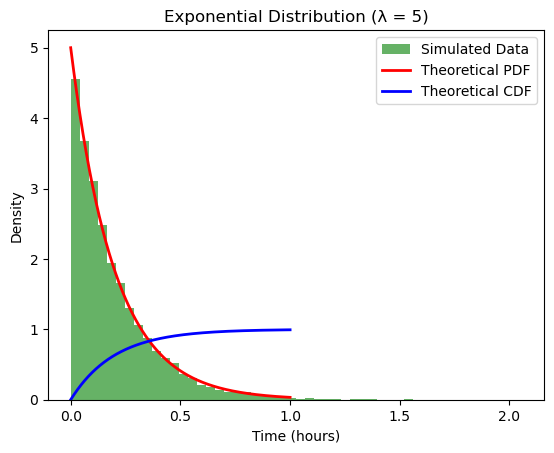

In [18]:
from scipy.stats import expon


lambda_rate = 5 # 5 buses per hour
scale = 1 / lambda_rate # mean time between buses, 12 mins per bus

data = expon.rvs(scale=scale, size=10000) # sample date for 10000 bus arrivals

print("Sample Mean:", np.mean(data))
print("Theoretical Mean:", 1/lambda_rate)

# Calculating for x = 0.3 hours or 18 mins
print("PDF:", expon.pdf(0.3, scale=scale))
print("CDF P(X <= 0.3):", expon.cdf(0.3, scale=scale))
print("Survivial probability P(X > 0.3):", expon.sf(0.3, scale=scale))

x = np.linspace(0, 1, 1000)

plt.hist(data, bins=50, density=True, alpha=0.6, color='green', label="Simulated Data")
plt.plot(x, expon.pdf(x, scale=scale), 'r', linewidth=2, label="Theoretical PDF")
plt.plot(x, expon.cdf(x, scale=scale), 'b', linewidth=2, label="Theoretical CDF")

plt.title("Exponential Distribution (λ = 5)")
plt.xlabel("Time (hours)")
plt.ylabel("Density")
plt.legend()
plt.show()

## Weibull distribution
$\text{These are based on dependant events, for example finding when the engine will fail next because it is natural for the engine to wear and tear over time}\\$
$\text{Slope parameter (k) > 1, the older the system, the more likely it fails soon}$
$\text{NOTE: Exponential distribution is memoryless but Weibull is not (except when k=1, here it becomes like exponential)}\\$

$\text{The function below is the PDF (probability density function)}$

$$
f(x; k, \lambda) =
\begin{cases}
\frac{k}{\lambda} \left(\frac{x}{\lambda}\right)^{k-1}
e^{-(x/\lambda)^k}, & x \ge 0 \\
0, & x < 0
\end{cases}
$$

Where:

- $k > 0$ = shape parameter, controls failure behavior k<1 = decreasing failure rates; k=1 = constant failure rates; k>1 = increasing failure rates
- $\lambda > 0$ = scale parameter, streches or shrinks the distribution, laeger $\lambda$ = longer lifetime

$\text{CDF function is obtained after integrating PDF:}$
$$
F(x) = 1 - e^{(- x/\lambda)^k} 
$$

$\text{Survival function}$
$$
S(x) = 1 - F(x)
$$

Survivial probability P(X > 1200): 0.23692775868212176
CDF P(X <= 1200): 0.7630722413178782


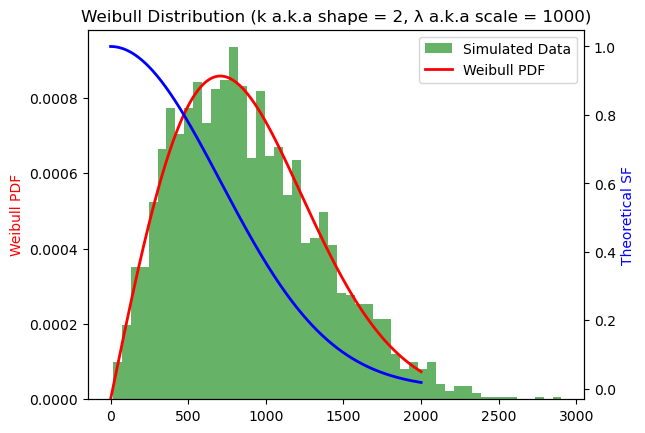

In [19]:
from scipy.stats import weibull_min

# Suppose a company studies the lifetime of its light bulbs and finds it follows a Weibull distribution with:
#   Shape parameter k=2
#   Scale parameter 𝜆 = 1000 hours

# QUESTION: WHAT IS Probability a bulb lasts more than 1200 hours?

shape = 2
scale = 1000 # characteristic life


# Create distribution object
weibull_dist = weibull_min(c=shape, scale=scale)
# generate ramdom samples for 5000 lifetimes
wei_data = weibull_dist.rvs(size=3000)

# Generate x values
x = np.linspace(0, 2000, 500)

#print("PDF:", weibull_dist.pdf(x))
print("Survivial probability P(X > 1200):", weibull_dist.sf(x=1200))
print("CDF P(X <= 1200):", weibull_dist.cdf(x=1200))


fig, ax1 = plt.subplots()

plt.hist(wei_data, bins=50, density=True, alpha=0.6, color='green', label="Simulated Data")
ax1.plot(x, weibull_dist.pdf(x), 'r', linewidth=2, label="Weibull PDF")
ax1.set_ylabel("Weibull PDF", color='r')

ax2 = ax1.twinx()

ax2.plot(x, weibull_dist.sf(x), 'b', linewidth=2, label="Theoretical SF")
ax2.set_ylabel("Theoretical SF", color='b')

plt.title("Weibull Distribution (k a.k.a shape = 2, λ a.k.a scale = 1000)")
ax1.legend()
plt.show()


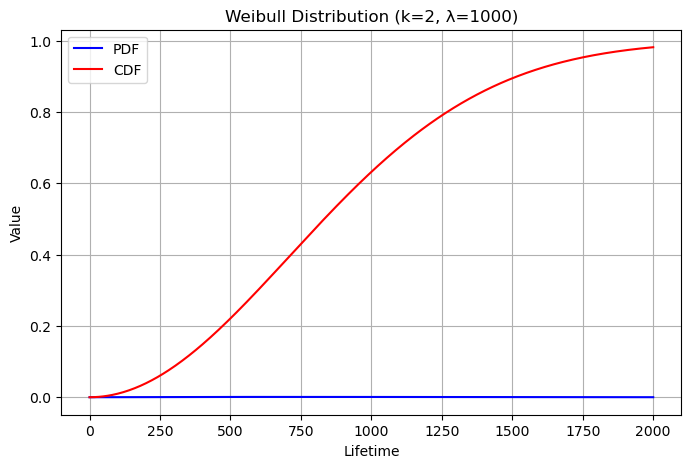

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

# Parameters
k = 2        # shape parameter
lam = 1000   # scale parameter

# Create distribution
weibull_dist = weibull_min(c=k, scale=lam)

# X values
x = np.linspace(0, 2000, 500)

# PDF and CDF
pdf = weibull_dist.pdf(x)
cdf = weibull_dist.cdf(x)

# Plot
plt.figure(figsize=(8,5))
plt.plot(x, pdf, label="PDF", color="blue")
plt.plot(x, cdf, label="CDF", color="red")

plt.title("Weibull Distribution (k=2, λ=1000)")
plt.xlabel("Lifetime")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()